# Validación temporal del modelo de café

## tl;dr

- El objetivo original es continuo: `rendimiento_t_ha`. Para la matriz de confusión se define `rendimiento alto` como un valor superior a **0.923337 t/ha**, mediana de 2007-2018 fijada sin mirar el futuro.
- El modelo elegido con 2019-2023 fue **Regresión logística balanceada**. En el holdout 2024 obtuvo precisión **0.961**, exactitud **0.746**, balanced accuracy **0.802** y MCC **0.546**.
- En 2024, **Random Forest balanceado** tuvo el MCC observado más alto (0.565), pero no se usó para cambiar retrospectivamente al ganador.
- Matriz 2024, filas reales y columnas predichas (`bajo`, `alto`): `[[166, 12], [146, 299]]`.
- La validación es **compartible con cautelas**: hay drift entre años, cambio de fuente en 2019 y variables externas con trazabilidad insuficiente.


## Context & Methods

### Key Assumptions

1. La unidad es municipio-cultivo-año.
2. El umbral de clase permanece fijo después de calcularse con 2007-2018.
3. Los modelos se seleccionan con backtest rolling-origin 2019-2023.
4. El año 2024 queda reservado como holdout final.
5. MCC promedio anual es el criterio primario; balanced accuracy desempata.
6. `score_confiabilidad` y `dato_copiado` se excluyen porque dependen del target.
7. Las variables externas se muestran solo como sensibilidad exploratoria; no pueden ganar.

La clase es **rendimiento alto**, no beneficio financiero ni prosperidad empresarial.


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUT = ROOT / "reports" / "validacion_modelo"

# Cambiar a True para recalcular todos los modelos (~5 minutos en la máquina validada).
FORCE_RETRAIN = False
from src.evaluation.validate_models import run_validation
summary = run_validation(output_dir=OUT, force=FORCE_RETRAIN)
summary

{'data_path': 'reports\\tablas_entrenamiento\\dataset_cafe_ml_ready.csv',
 'rows': 10973,
 'columns': 48,
 'threshold_high_yield_t_ha': 0.9233366394115502,
 'selection_years': [2019, 2020, 2021, 2022, 2023],
 'holdout_year': 2024,
 'classification_winner': 'Regresión logística balanceada',
 'classification_holdout_2024': {'accuracy': 0.7463884430176565,
  'balanced_accuracy': 0.8022471910112359,
  'precision': 0.9614147909967846,
  'recall': 0.6719101123595506,
  'f1': 0.791005291005291,
  'mcc': 0.5461661550080222},
 'confusion_matrix_2024': [[166, 12], [146, 299]],
 'regression_winner': 'Random Forest Regressor',
 'regression_holdout_2024': {'mae': 0.26954937570715354,
  'rmse': 0.35505234645157663,
  'r2': 0.17706863833134778},
 'status': 'Compartible con cautelas'}

## Data

In [2]:
data = pd.read_csv(ROOT / summary["data_path"])
quality = pd.read_csv(OUT / "calidad_datos.csv")
balance = pd.read_csv(OUT / "balance_clases.csv")
print(f"Filas: {len(data):,} | Columnas: {data.shape[1]} | Años: {data.anio.min()}-{data.anio.max()}")
display(quality)
display(balance)

Filas: 10,973 | Columnas: 48 | Años: 2007-2024


,chequeo,valor,interpretacion
0,filas,10973,informativo
1,columnas,48,informativo
2,duplicados_clave,0,alto si > 0
3,target_nulos,0,alto si > 0
4,lag1_comparaciones,10215,informativo
5,lag1_inconsistencias,0,alto si > 0
6,municipios_compuestos,683,informativo
7,nombres_municipio_homonimos,39,riesgo de join
8,filas_afectadas_homonimos,1369,riesgo de join
9,score_confiabilidad_target_derivado,1,fuga si se usa


,periodo,n,bajo_0,alto_1,alto_pct,ratio_mayoritaria_minoritaria
0,entrenamiento_2007_2018,6513,3223,3290,0.505144,1.020788
1,seleccion_2019_2023,3079,1047,2032,0.659955,1.940783
2,holdout_2024,623,178,445,0.714286,2.500000
3,2019,579,61,518,0.894646,8.491803
4,2020,619,125,494,0.798061,3.952000
5,2021,625,189,436,0.697600,2.306878
6,2022,631,338,293,0.464342,1.153584
7,2023,625,334,291,0.465600,1.147766
8,2024,623,178,445,0.714286,2.500000


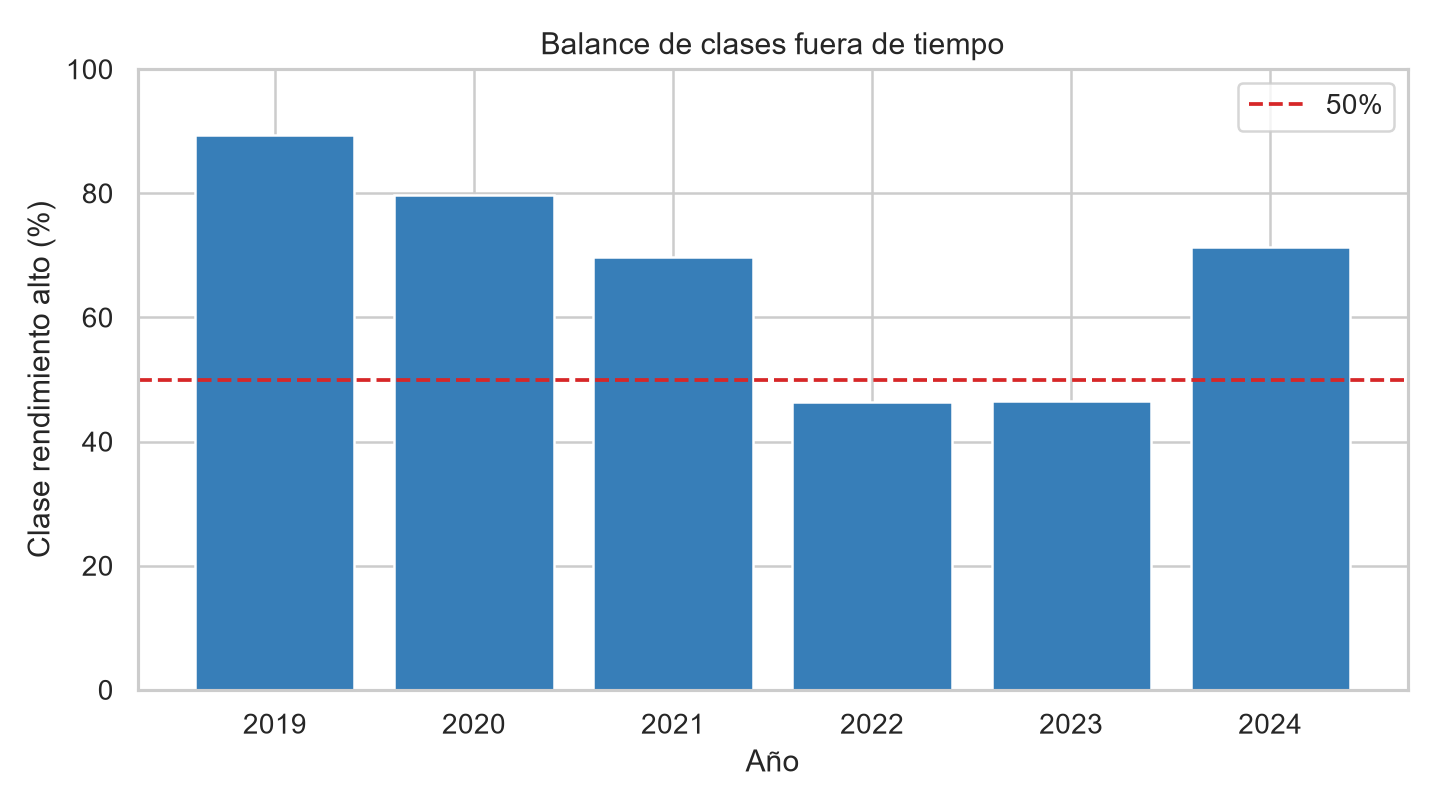

In [3]:
display(Image(filename=str(OUT / "balance_clases.png")))

El histórico utilizable está prácticamente balanceado, pero las pruebas no: la clase alta representa 89,5% en 2019, 46,4% en 2022 y 71,4% en 2024. Por eso accuracy sola sería engañosa y se prioriza MCC.


## Results

,modelo,elegible_como_ganador,n,mcc_promedio_anual,mcc_minimo_anual,accuracy,balanced_accuracy,precision,recall,f1,mcc
0,Regresión logística balanceada,True,3079,0.3580,0.1041,0.7308,0.6891,0.7828,0.8194,0.8007,0.3876
1,Regla rendimiento t-1,True,3079,0.3552,0.1034,0.7363,0.6914,0.7824,0.8317,0.8063,0.3963
2,Random Forest balanceado,True,3079,0.3093,0.1201,0.7191,0.6522,0.7501,0.8612,0.8018,0.3365
3,CatBoost balanceado,True,3079,0.3083,0.1104,0.7174,0.6697,0.7682,0.8189,0.7928,0.3521
4,Mayoría del entrenamiento,True,3079,0.0000,0.0000,0.6600,0.5000,0.6600,1.0000,0.7951,0.0000
5,CatBoost + externas (exploratorio),False,3079,0.3068,0.1090,0.7168,0.6678,0.7665,0.8209,0.7928,0.3493


,modelo,elegible_como_ganador,n,mcc_promedio_anual,mcc_minimo_anual,accuracy,balanced_accuracy,precision,recall,f1,mcc
0,Random Forest balanceado,True,623,0.5649,0.5649,0.7464,0.8124,0.9799,0.6584,0.7876,0.5649
1,Regla rendimiento t-1,True,623,0.5527,0.5527,0.7335,0.8051,0.9827,0.6382,0.7738,0.5527
2,Regresión logística balanceada,True,623,0.5462,0.5462,0.7464,0.8022,0.9614,0.6719,0.7910,0.5462
3,CatBoost balanceado,True,623,0.4629,0.4629,0.6501,0.7483,0.9830,0.5191,0.6794,0.4629
4,Mayoría del entrenamiento,True,623,0.0000,0.0000,0.7143,0.5000,0.7143,1.0000,0.8333,0.0000
5,CatBoost + externas (exploratorio),False,623,0.4426,0.4426,0.6308,0.7348,0.9821,0.4921,0.6557,0.4426


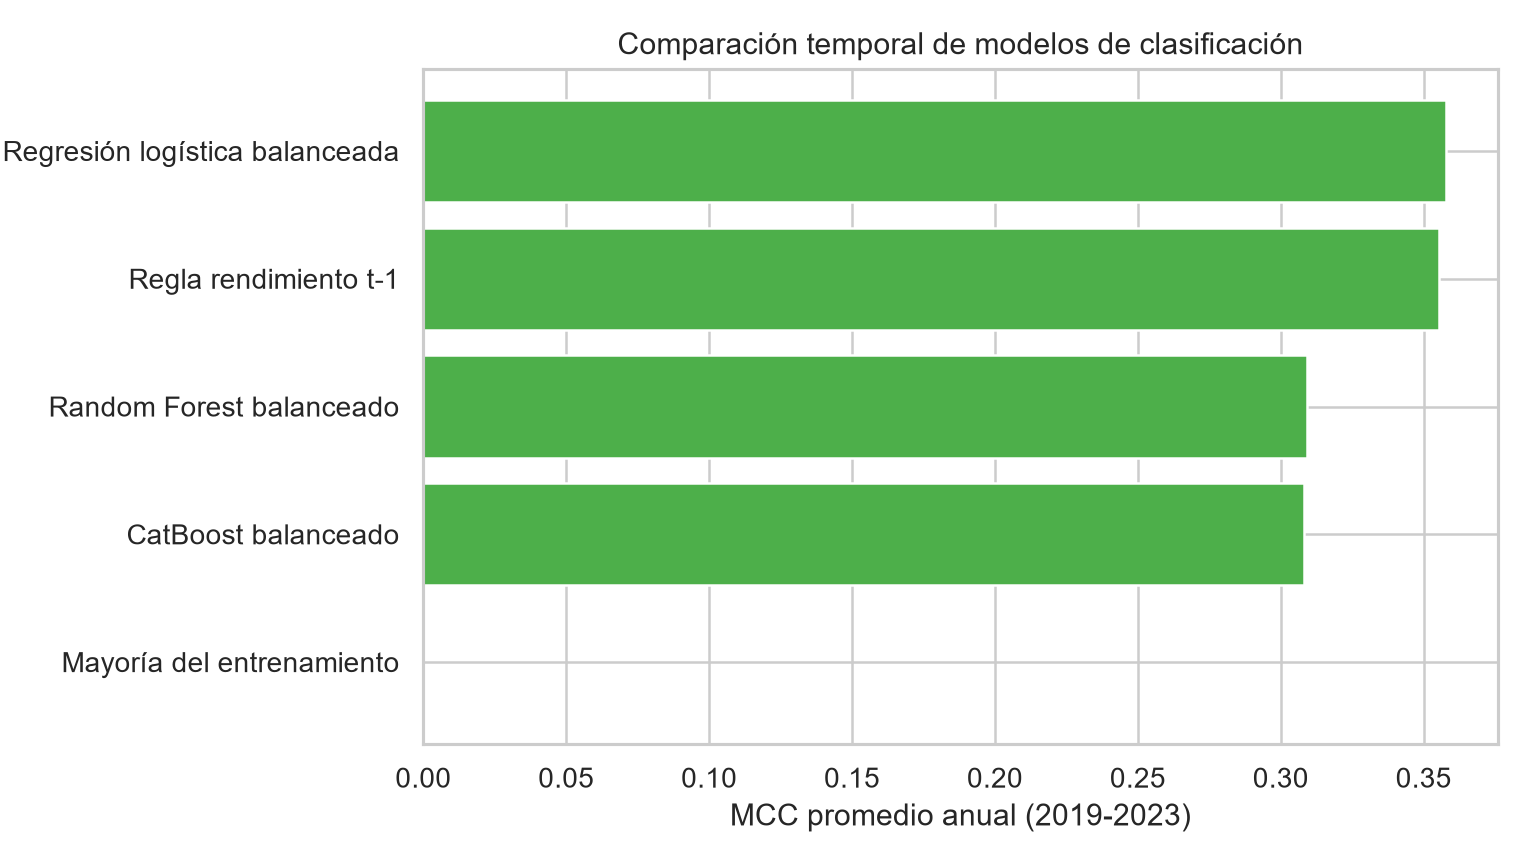

In [4]:
class_selection = pd.read_csv(OUT / "comparacion_clasificacion_seleccion.csv")
class_holdout = pd.read_csv(OUT / "comparacion_clasificacion_holdout_2024.csv")
display(class_selection.round(4))
display(class_holdout.round(4))
display(Image(filename=str(OUT / "comparacion_modelos_mcc.png")))

,pred_bajo,pred_alto
real_bajo,166,12
real_alto,146,299


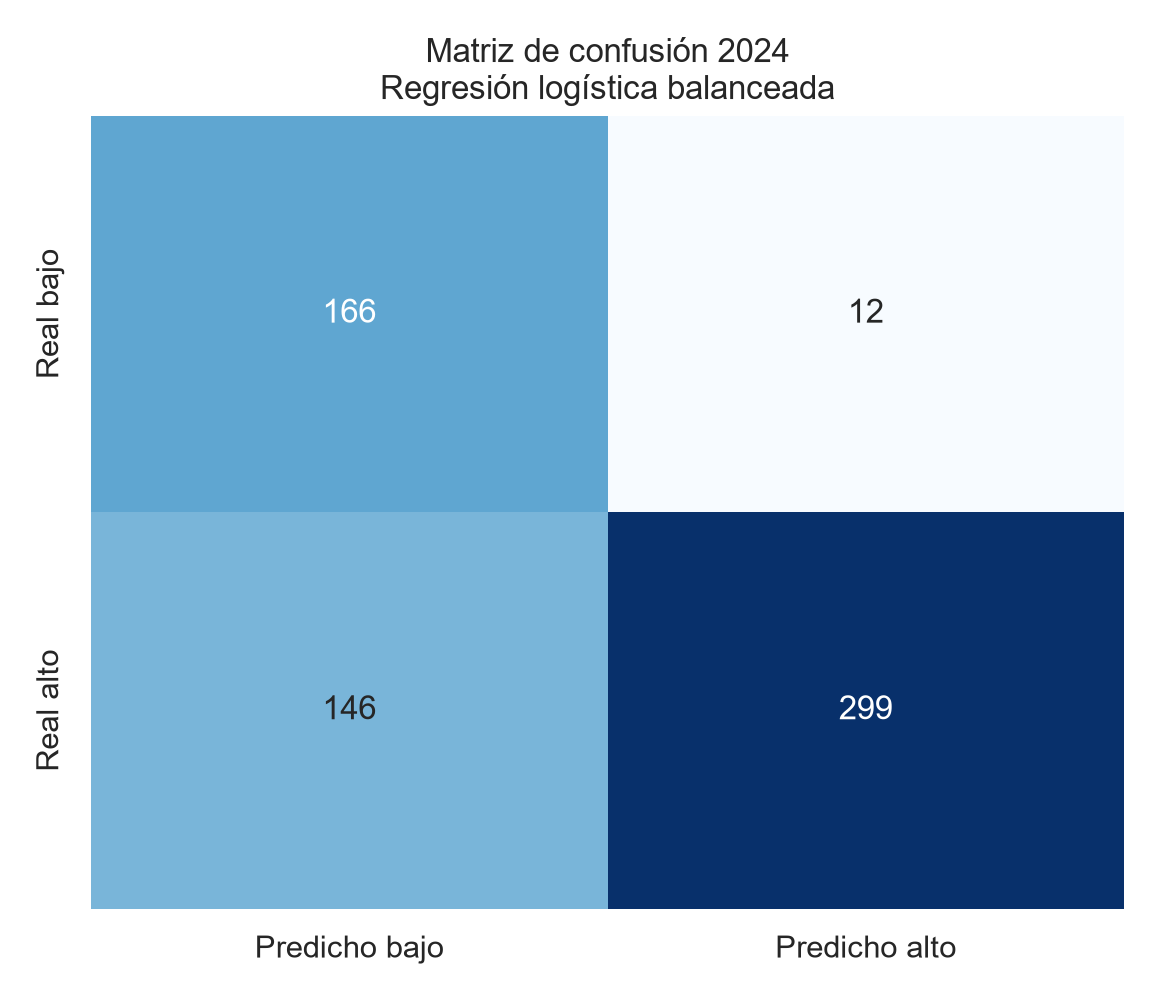

In [5]:
matrix = pd.read_csv(OUT / "matriz_confusion_mejor_modelo.csv", index_col=0)
display(matrix)
display(Image(filename=str(OUT / "matriz_confusion_mejor_modelo.png")))

La regresión logística gana por un margen mínimo frente a la regla `rendimiento t-1`. La diferencia no es suficiente para afirmar superioridad concluyente: el baseline gana en tres de los cinco años de selección y los resultados cambian con el año.


In [6]:
reg_selection = pd.read_csv(OUT / "comparacion_regresion_seleccion.csv")
reg_holdout = pd.read_csv(OUT / "comparacion_regresion_holdout_2024.csv")
display(reg_selection.round(4))
display(reg_holdout.round(4))

,modelo,elegible_como_ganador,n,mae_promedio_anual,mae_maximo_anual,mae,rmse,r2
0,Random Forest Regressor,True,2974,0.2026,0.2383,0.2032,0.2737,0.1519
1,CatBoost Regressor,True,2974,0.2107,0.2844,0.2105,0.2900,0.0482
2,Elastic Net,True,2974,0.2287,0.2768,0.2290,0.2992,-0.0132
3,Baseline rendimiento t-1,True,2974,0.2287,0.3225,0.2277,0.3204,-0.1617
4,Baseline media móvil 3 años,True,2974,0.2444,0.2704,0.2445,0.3119,-0.1010
5,CatBoost Regressor + externas (exploratorio),False,2974,0.2105,0.2862,0.2103,0.2895,0.0513


,modelo,elegible_como_ganador,n,mae_promedio_anual,mae_maximo_anual,mae,rmse,r2
0,Elastic Net,True,623,0.2184,0.2184,0.2184,0.2937,0.4368
1,Baseline media móvil 3 años,True,623,0.2359,0.2359,0.2359,0.3191,0.3354
2,Baseline rendimiento t-1,True,623,0.2479,0.2479,0.2479,0.3114,0.3670
3,Random Forest Regressor,True,623,0.2695,0.2695,0.2695,0.3551,0.1771
4,CatBoost Regressor,True,623,0.2794,0.2794,0.2794,0.3471,0.2137
5,CatBoost Regressor + externas (exploratorio),False,623,0.2850,0.2850,0.2850,0.3533,0.1851


## Takeaways

1. **Clasificación:** Regresión logística balanceada es el ganador formal del período de selección, con precisión 2024 de 96.1% y MCC 0.546. El margen de selección fue mínimo y Random Forest balanceado alcanzó MCC 0.565 en 2024, por lo que no hay superioridad estable.
2. **Balance:** el entrenamiento histórico está balanceado, pero hay desbalance y drift fuerte fuera de tiempo; MCC y balanced accuracy son indispensables.
3. **Regresión:** Random Forest Regressor gana en 2019-2023, pero su R² cae a 0.177 en 2024; el desempeño no es estable.
4. **Riesgos:** deben reconstruirse `score_confiabilidad` solo con historia previa y corregirse joins de suelo/crédito con `departamento + municipio` antes de usar variables externas.
5. **Decisión:** el resultado sirve como validación académica con cautelas, no todavía como soporte suficiente para una inversión agrícola.
